In [ ]:
!pip -q install -U ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.4 MB/s eta 0:00:00


In [ ]:
!pip install opencv.python

In [ ]:
from ultralytics import YOLO
model = YOLO("yolov8n.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
from google.colab.output import eval_js
from base64 import b64decode
import cv2
import numpy as np
from IPython.display import display
from PIL import Image

def take_photo(quality=0.8):
    js = r'''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.width = '480px';
      video.style.height = '360px';
      video.setAttribute('playsinline', '');
      div.appendChild(video);

      document.body.appendChild(div);

      const stream = await navigator.mediaDevices.getUserMedia({video: true});
      video.srcObject = stream;
      await video.play();

      // Wait for user to click Capture
      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);

      stream.getTracks().forEach(track => track.stop());
      div.remove();

      return canvas.toDataURL('image/jpeg', quality);
    }
    '''
    data = eval_js(js + f"takePhoto({quality})")
    binary = b64decode(data.split(',')[1])
    jpg_as_np = np.frombuffer(binary, dtype=np.uint8)
    img = cv2.imdecode(jpg_as_np, cv2.IMREAD_COLOR)  # BGR
    return img

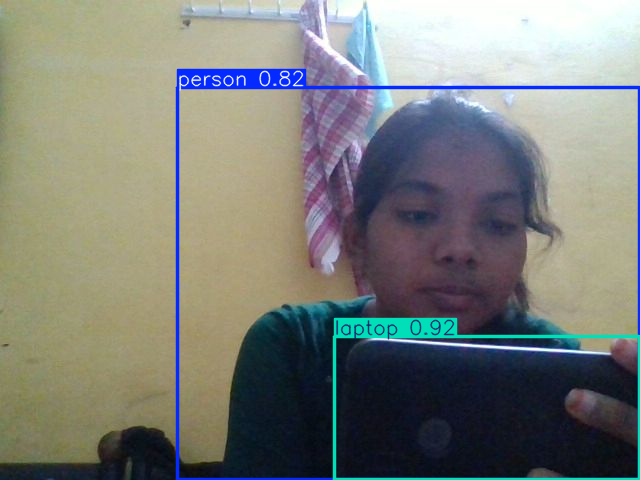

In [ ]:
img_bgr = take_photo()

results = model.predict(source=img_bgr, conf=0.25, verbose=False)
annotated_bgr = results[0].plot()  # draws boxes

# Convert BGR -> RGB for display
annotated_rgb = cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB)
display(Image.fromarray(annotated_rgb))